In [28]:
# Ensure that the correct Python interpreter is being used (.venv)
import sys
print(sys.executable)

/home/erithacus/ClassRoom/Steven_SWE/.venv/bin/python


In [29]:
%pip install google-cloud-bigquery google-cloud-bigquery-storage google-cloud-storage pandas seaborn db-dtypes

Note: you may need to restart the kernel to use updated packages.


In [30]:
DATASET_TABLE = "bigquery-public-data.ml_datasets.credit_card_default"
SAMPLE_SIZE = 10000
TARGET_COL = "default_payment_next_month"

In [31]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize client and load data
bq_client = bigquery.Client()
bq_query = f"""
SELECT
  id,
  limit_balance,
  sex,
  education_level,
  marital_status,
  age,
  pay_0,
  pay_2,
  pay_3,
  pay_4,
  pay_5,
  pay_6,
  bill_amt_1,
  bill_amt_2,
  bill_amt_3,
  bill_amt_4,
  bill_amt_5,
  bill_amt_6,
  pay_amt_1,
  pay_amt_2,
  pay_amt_3,
  pay_amt_4,
  pay_amt_5,
  pay_amt_6,
  default_payment_next_month
FROM `{DATASET_TABLE}` LIMIT {SAMPLE_SIZE}
"""
df = bq_client.query(bq_query).to_dataframe()

# Convert the string target to numeric for easier plotting, as the schema defines it as STRING [1]
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
# Fix BigQuery schema inconsistencies: Convert text columns to numeric
df["pay_5"] = pd.to_numeric(df["pay_5"], errors="coerce")
df["pay_6"] = pd.to_numeric(df["pay_6"], errors="coerce")
df.head()

,id,limit_balance,sex,education_level,marital_status,age,pay_0,pay_2,pay_3,pay_4,...,bill_amt_4,bill_amt_5,bill_amt_6,pay_amt_1,pay_amt_2,pay_amt_3,pay_amt_4,pay_amt_5,pay_amt_6,default_payment_next_month
0,27502.0,80000.0,1,6,1,54.0,0.0,0.0,0.0,0.0,...,29296.0,26210.0,17643.0,2545.0,2208.0,1336.0,2232.0,542.0,348.0,1
1,26879.0,200000.0,1,4,1,49.0,0.0,0.0,0.0,0.0,...,50146.0,50235.0,48984.0,1689.0,2164.0,2500.0,3480.0,2500.0,3000.0,0
2,18340.0,20000.0,2,6,2,22.0,0.0,0.0,0.0,0.0,...,1434.0,500.0,0.0,4641.0,1019.0,900.0,0.0,1500.0,0.0,1
3,13692.0,260000.0,2,4,2,33.0,0.0,0.0,0.0,0.0,...,27821.0,30767.0,29890.0,5000.0,5000.0,1137.0,5000.0,1085.0,5000.0,0
4,20405.0,150000.0,1,4,2,32.0,0.0,0.0,0.0,-1.0,...,150464.0,143375.0,146411.0,4019.0,146896.0,157436.0,4600.0,4709.0,5600.0,0


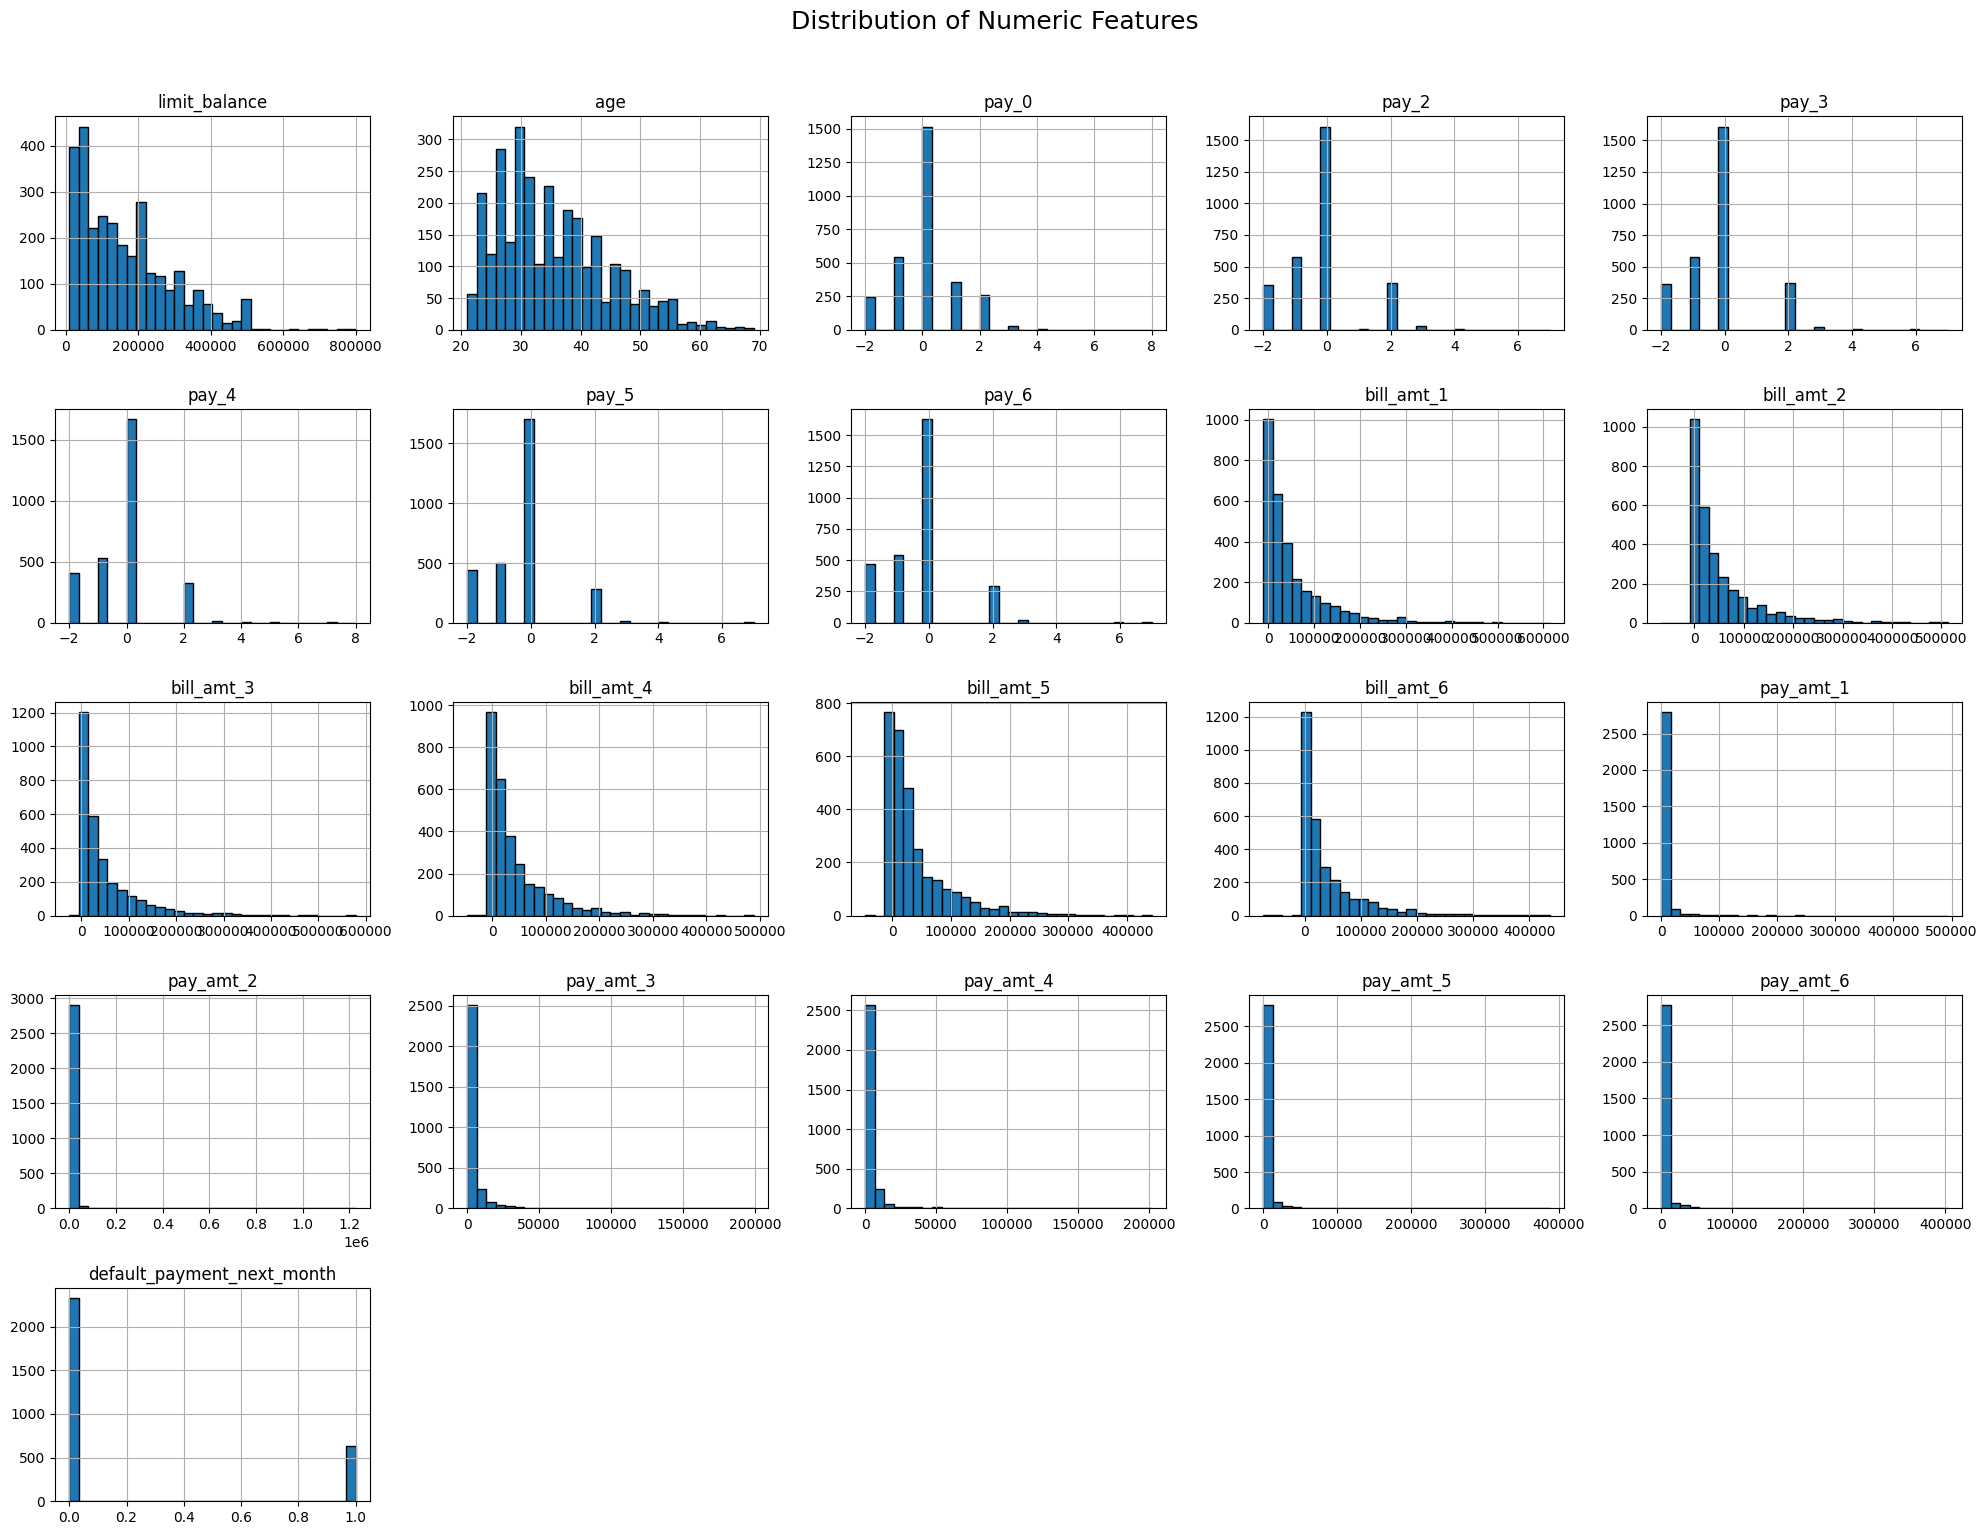

In [32]:
# Select numeric features based on the dataset schema [1]
# Note: sex, education_level, marital_status, pay_5, and pay_6 are STRINGs in BigQuery [1]
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns.drop(
    "id", errors="ignore"
)

df[numeric_cols].hist(figsize=(20, 15), bins=30, edgecolor="black")
plt.suptitle("Distribution of Numeric Features", y=1.02, fontsize=18)
plt.tight_layout()
plt.show()

In [33]:
# Calculate missing values
missing_summary = df.isnull().sum().to_frame(name="Missing Values")
missing_summary["% Missing"] = (missing_summary["Missing Values"] / len(df)) * 100
missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

print("Missing Value Summary Table:")
display(
    missing_summary
    if not missing_summary.empty
    else "No missing values found in the dataset."
)

Missing Value Summary Table:


'No missing values found in the dataset.'

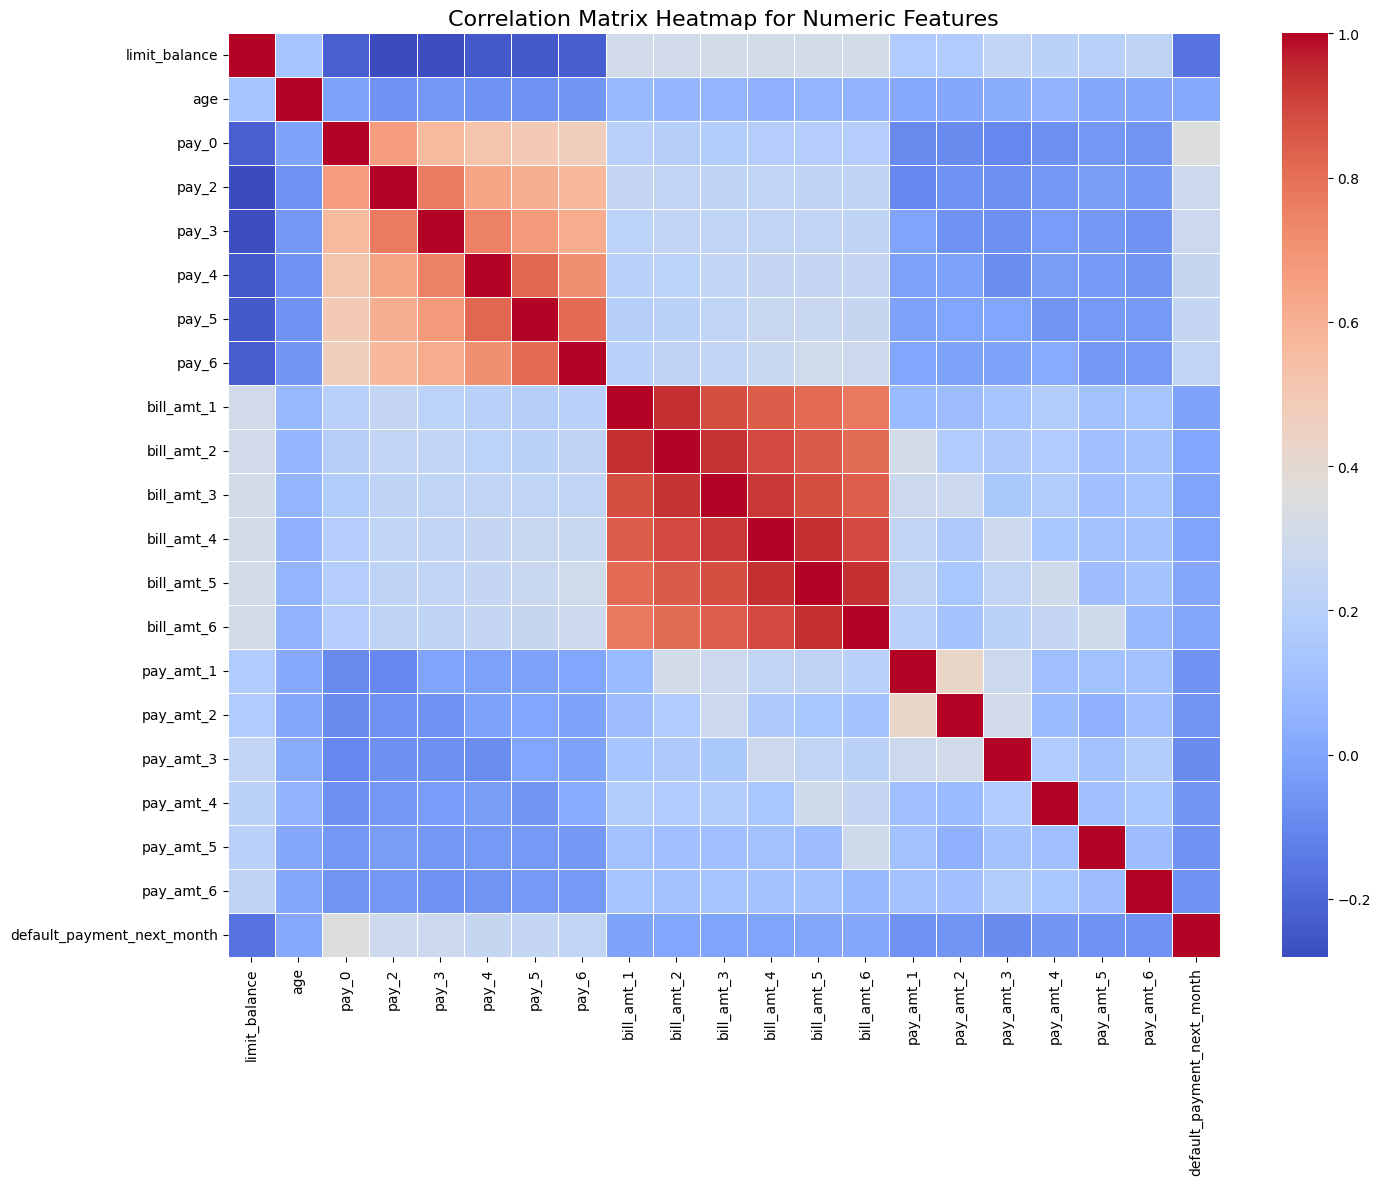

In [34]:
plt.figure(figsize=(16, 12))
# Compute correlation only on numeric columns
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap for Numeric Features", fontsize=16)
plt.show()

Class Balance (%):
default_payment_next_month
0    78.583474
1    21.416526
Name: proportion, dtype: float64


/tmp/ipykernel_20666/2087939332.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=TARGET_COL, palette="viridis")


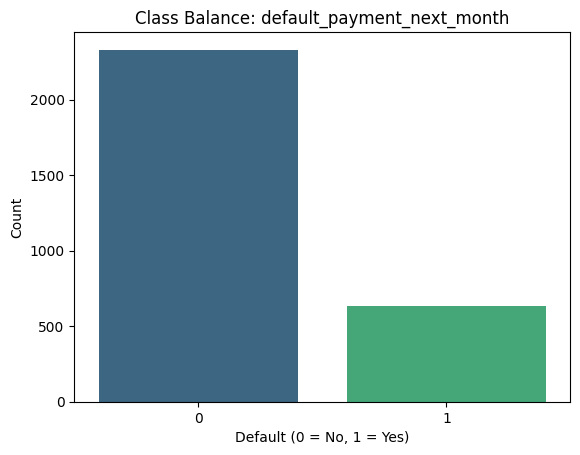

In [35]:
class_balance = df[TARGET_COL].value_counts(normalize=True) * 100
print("Class Balance (%):")
print(class_balance)

sns.countplot(data=df, x=TARGET_COL, palette="viridis")
plt.title(f"Class Balance: {TARGET_COL}")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

### EDA Observations
1. **Imbalanced Target:** The `default_payment_next_month` target variable is heavily imbalanced, with the vast majority of users (~78-80%) belonging to class 0 (No Default). This explains why we needed `class_weights` during our earlier BigQuery ML training.
2. **High Multicollinearity in Bill Amounts:** The correlation matrix heatmap reveals that `bill_amt_1` through `bill_amt_6` are highly positively correlated with each other. This indicates that a customer's bill amount rarely drastically changes month-to-month.
3. **Age Distribution:** The `age` feature is right-skewed, showing that the majority of the credit card holders in this dataset are between their mid-20s and late-30s.
4. **Data Quality (Missing Values):** The dataset is remarkably clean. The missing value summary table shows no null values across the sampled features, meaning heavy imputation was not required before modeling.
5. **Payment Amount Skewness:** The `pay_amt_1` through `pay_amt_6` distributions are heavily skewed to the right, indicating that most customers make relatively small payments, while a few outliers make exceptionally large payments.